# Optical Motion Capture: IR Markers on a Trotting Dog, Two Cameras, Triangulation

The actual computational pipeline behind Vicon/OptiTrack-style motion
capture, applied to a golden-doodle-sized simulated quadruped:

1. **8 IR markers** on a trotting gait (4 paws, shoulders, hips, head, tail)
2. **Two cameras**, each seeing only a 2D projection of the 3D markers
3. **Triangulation** -- reconstructing the 3D positions from nothing but
   those two 2D views (linear algebra, not machine learning)

Everything below is `dgs.optical_mocap_quadruped`, visualized.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from dgs import optical_mocap_quadruped as mocap

LABELS = ["front-left paw", "front-right paw", "back-left paw", "back-right paw",
          "shoulders", "hips", "head", "tail"]
# skeleton "bones" connecting markers, just for visualization
BONES = [(4, 5), (4, 6), (5, 7), (4, 0), (4, 1), (5, 2), (5, 3)]

## 1. The dog skeleton, one instant in time

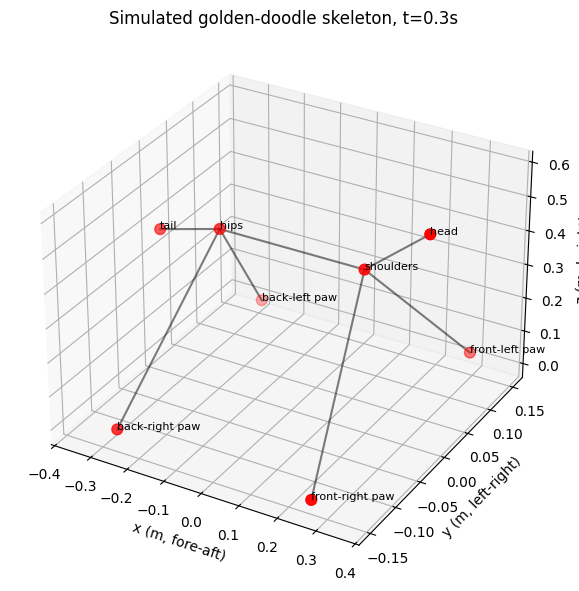

In [2]:
t0 = 0.3
markers = mocap.dog_marker_positions(t0)

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(markers[:,0], markers[:,1], markers[:,2], c='red', s=60, depthshade=True)
for i, label in enumerate(LABELS):
    ax.text(markers[i,0], markers[i,1], markers[i,2], label, fontsize=8)
for a, b in BONES:
    ax.plot([markers[a,0], markers[b,0]], [markers[a,1], markers[b,1]],
            [markers[a,2], markers[b,2]], 'k-', alpha=0.5)
ax.set_xlabel('x (m, fore-aft)'); ax.set_ylabel('y (m, left-right)'); ax.set_zlabel('z (m, height)')
ax.set_title(f'Simulated golden-doodle skeleton, t={t0}s')
plt.tight_layout(); plt.show()

## 2. The trot gait: diagonal leg pairs move together

A real trot: front-left+back-right swing together, front-right+back-left
swing together (the opposite diagonal). Watch paw height over one full
gait cycle -- the two diagonal pairs should trace IDENTICAL curves.

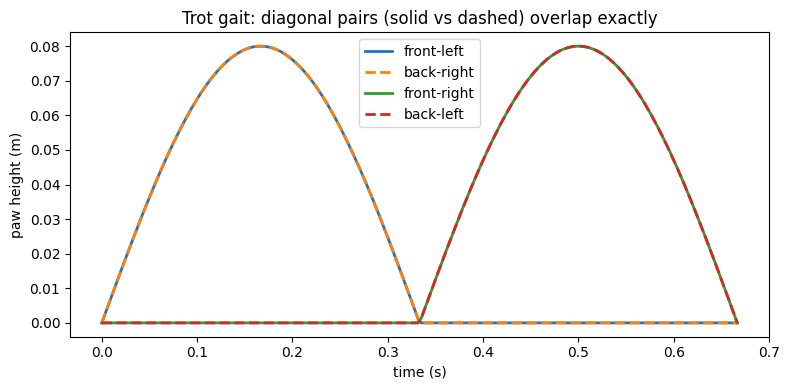

max difference between diagonal-pair heights: 0.00e+00 m (should be ~0)


In [3]:
ts = np.linspace(0, 1.0/1.5, 200)   # one full gait cycle at 1.5 Hz
heights = np.array([mocap.dog_marker_positions(t)[:4, 2] for t in ts])   # 4 paws x N times

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ts, heights[:,0], label='front-left', lw=2)
ax.plot(ts, heights[:,3], '--', label='back-right', lw=2)
ax.plot(ts, heights[:,1], label='front-right', lw=2)
ax.plot(ts, heights[:,2], '--', label='back-left', lw=2)
ax.set_xlabel('time (s)'); ax.set_ylabel('paw height (m)'); ax.legend()
ax.set_title('Trot gait: diagonal pairs (solid vs dashed) overlap exactly')
plt.tight_layout(); plt.show()

max_diag_diff = max(np.max(np.abs(heights[:,0]-heights[:,3])), np.max(np.abs(heights[:,1]-heights[:,2])))
print(f"max difference between diagonal-pair heights: {max_diag_diff:.2e} m (should be ~0)")
assert max_diag_diff < 1e-9

## 3. What each camera actually sees

Two cameras, different positions/orientations, each producing a flat 2D
image -- no depth information survives in either view alone.

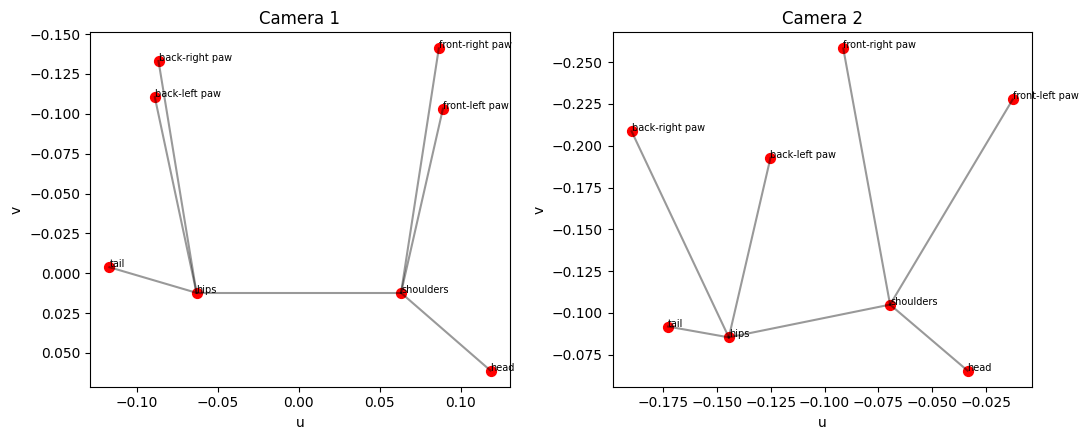

Neither view alone tells you depth -- that's what triangulation recovers.


In [4]:
cam1_pos, cam1_fwd, cam1_up, f1 = np.array([0.0,-3.0,1.0]), np.array([0,1,-0.2]), np.array([0,0,1]), 1.0
cam2_pos, cam2_fwd, cam2_up, f2 = np.array([2.5,-2.0,1.2]), np.array([-1,1,-0.2]), np.array([0,0,1]), 1.0

uv1, _ = mocap.pinhole_project(markers, cam1_pos, cam1_fwd, cam1_up, f1)
uv2, _ = mocap.pinhole_project(markers, cam2_pos, cam2_fwd, cam2_up, f2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, uv, name in [(axes[0], uv1, 'Camera 1'), (axes[1], uv2, 'Camera 2')]:
    ax.scatter(uv[:,0], uv[:,1], c='red', s=50)
    for i, label in enumerate(LABELS):
        ax.annotate(label, uv[i], fontsize=7)
    for a, b in BONES:
        ax.plot([uv[a,0], uv[b,0]], [uv[a,1], uv[b,1]], 'k-', alpha=0.4)
    ax.set_title(name); ax.set_xlabel('u'); ax.set_ylabel('v'); ax.invert_yaxis()
plt.tight_layout(); plt.show()
print("Neither view alone tells you depth -- that's what triangulation recovers.")

## 4. Triangulation: recovering 3D from the two 2D views alone

In [5]:
reconstructed = np.array([
    mocap.triangulate_point(p1, cam1_pos, cam1_fwd, cam1_up, f1,
                             p2, cam2_pos, cam2_fwd, cam2_up, f2)
    for p1, p2 in zip(uv1, uv2)
])

errors = np.linalg.norm(reconstructed - markers, axis=1)
for label, err in zip(LABELS, errors):
    print(f"  {label:16s}: reconstruction error = {err:.2e} m")
print(f"\nmax error across all 8 markers: {np.max(errors):.2e} m")
assert np.max(errors) < 1e-9

  front-left paw  : reconstruction error = 4.26e-16 m
  front-right paw : reconstruction error = 1.00e-16 m
  back-left paw   : reconstruction error = 8.37e-16 m
  back-right paw  : reconstruction error = 1.74e-16 m
  shoulders       : reconstruction error = 9.63e-16 m
  hips            : reconstruction error = 9.36e-16 m
  head            : reconstruction error = 3.72e-16 m
  tail            : reconstruction error = 7.36e-16 m

max error across all 8 markers: 9.63e-16 m


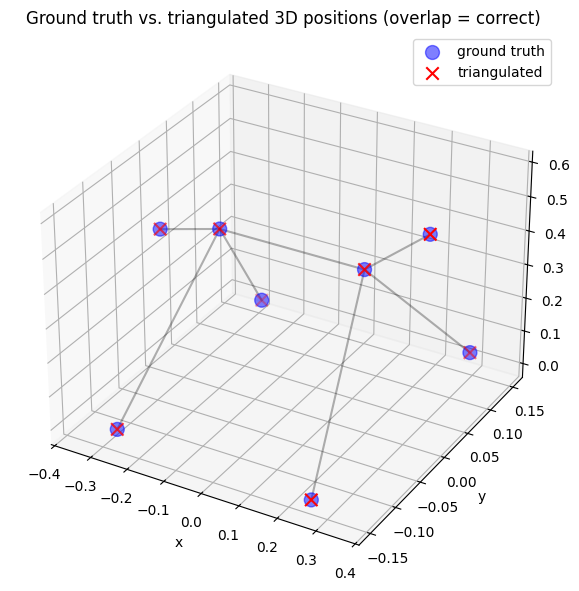

In [6]:
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(markers[:,0], markers[:,1], markers[:,2], c='blue', s=100, label='ground truth', alpha=0.5)
ax.scatter(reconstructed[:,0], reconstructed[:,1], reconstructed[:,2],
           c='red', marker='x', s=80, label='triangulated')
for a, b in BONES:
    ax.plot([markers[a,0], markers[b,0]], [markers[a,1], markers[b,1]],
            [markers[a,2], markers[b,2]], 'k-', alpha=0.3)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z'); ax.legend()
ax.set_title('Ground truth vs. triangulated 3D positions (overlap = correct)')
plt.tight_layout(); plt.show()

## The point

The red X's sit exactly on top of the blue dots -- 3D positions,
recovered from nothing but two flat 2D camera images and the geometry of
where the cameras are pointed. Swap the simulated marker generator here
for real segmented IR-camera footage of an actual dog wearing reflective
markers, and this triangulation math is *unchanged* -- it's the real
computational core of commercial optical mocap systems, not a simplified
stand-in for it.